In [1]:
%matplotlib widget

import random
import statistics

from typing import Dict, Optional
import matplotlib.pyplot as plt

import mplcursors

In [71]:
def pair_score(count: int) -> int:
    pairs = count // 2
    return pairs * (pairs + 1) // 2

def run_one_simulation(
    num_yellow: int,
    num_blue: int,
    num_black: int,
    black_limit: int,
    rng: Optional[random.Random] = None,
) -> Dict[str, object]:
    if rng is None:
        rng = random.Random()

    bag = (
        ["yellow"] * num_yellow +
        ["blue"] * num_blue +
        ["black"] * num_black
    )
    rng.shuffle(bag)

    yellow = 0
    blue = 0
    black = 0

    for ball in bag:
        if ball == "yellow":
            yellow += 1
        elif ball == "blue":
            blue += 1
        else:
            black += 1
            if black == black_limit:
                break

    # Test effect of green:
    '''while yellow > blue + 1 or blue > yellow + 1:
        if yellow > blue:
            yellow -= 1
            blue += 1
        else:
            yellow += 1
            blue -=1'''

    yellow_score = pair_score(yellow)
    blue_score = pair_score(blue)

    if yellow >= blue:
        majority_class = "yellow"
        majority_score = yellow_score
        minority_class = "blue"
        minority_score = blue_score
    else:
        majority_class = "blue"
        majority_score = blue_score
        minority_class = "yellow"
        minority_score = yellow_score

    total_score = majority_score + 2 * minority_score

    return {
        "yellow_drawn": yellow,
        "blue_drawn": blue,
        "yellow_score": yellow_score,
        "blue_score": blue_score,
        "majority_class": majority_class,
        "minority_class": minority_class,
        "majority_score": majority_score,
        "minority_score": minority_score,
        "total_score": total_score,
    }

def run_many_simulations(
    num_yellow: int,
    num_blue: int,
    num_black: int,
    black_limit: int,
    n_simulations: int = 100_000,
    seed: int = 0,
) -> Dict[str, object]:
    rng = random.Random(seed)
    results = [
        run_one_simulation(num_yellow, num_blue, num_black, black_limit, rng)
        for _ in range(n_simulations)
    ]

    majority_scores = [r["majority_score"] for r in results]
    minority_scores = [r["minority_score"] for r in results]
    total_scores = [r["total_score"] for r in results]

    return {
        "n_simulations": n_simulations,
        "num_yellow": num_yellow,
        "num_blue": num_blue,
        "num_black": num_black,
        "mean_majority_score": statistics.median(majority_scores),
        "mean_minority_score": statistics.median(minority_scores),
        "mean_total_score": statistics.median(total_scores),
        "example_simulation": results[0],
    }


def plot_summaries(summaries, xlabel="x"):
    x = list(range(1, len(summaries) + 1))

    majority = [s["mean_majority_score"] for s in summaries]
    minority = [s["mean_minority_score"] * 2 for s in summaries]
    total = [s["mean_total_score"] for s in summaries]

    labels = [
        f"Y{s['num_yellow']}_B{s['num_blue']}_K{s['num_black']}"
        for s in summaries
    ]

    plt.figure()
    line1, = plt.plot(x, majority, marker="o", label="mean majority")
    line2, = plt.plot(x, minority, marker="o", label="mean minority")
    line3, = plt.plot(x, total, marker="o", label="mean total")

    plt.xlabel(xlabel)
    plt.ylabel("median score")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

## Score by bag size
Distribution: [1.5, 1.5, 1]

End: 2 black

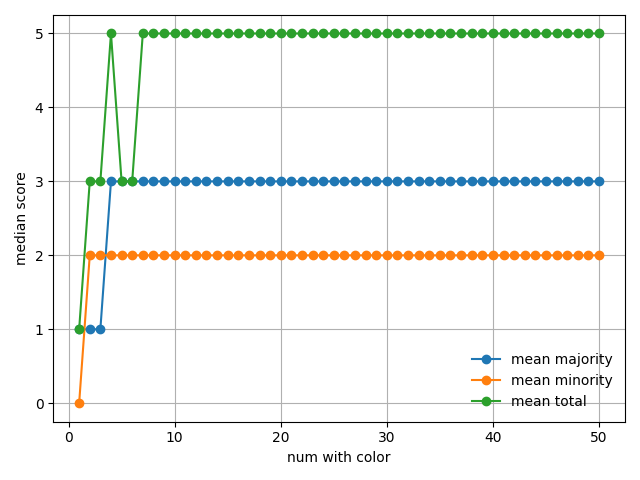

In [72]:
summaries = [run_many_simulations(
    num_yellow=n,
    num_blue=n,
    num_black=2*n // 3,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(1, 51)]

plot_summaries(summaries, xlabel="num with color")

Median minority is twice that of majority. Ie, by default minority is better than majority with equal balance.

## Score by tolerance
Bag: [6, 6, 4] & [24, 24, 16]

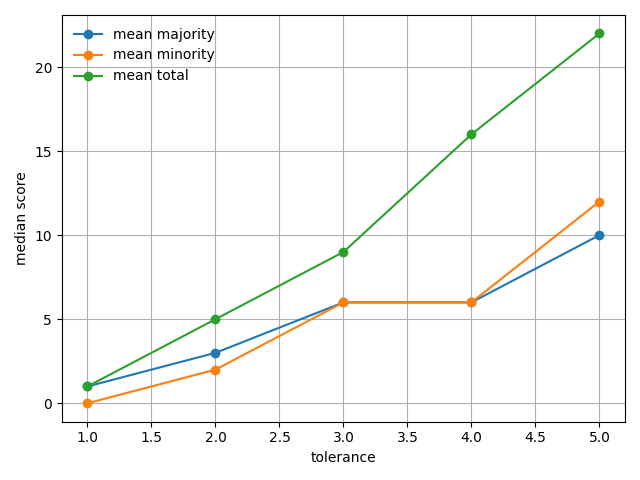

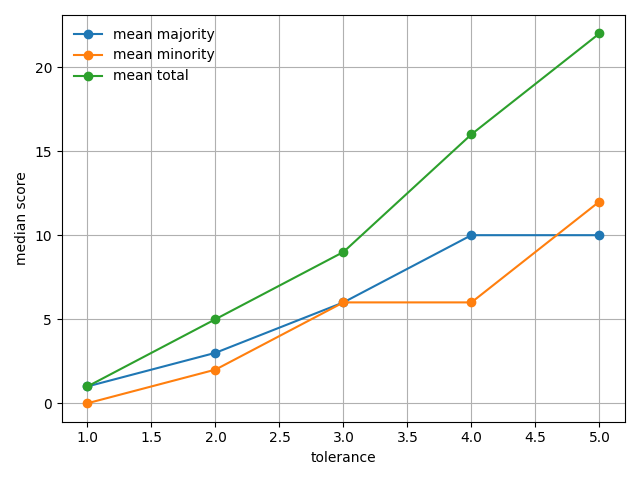

In [69]:
summaries = [run_many_simulations(
    num_yellow=6,
    num_blue=6,
    num_black=4,
    black_limit=n,
    n_simulations=10000,
    seed=42,
) for n in range(1, 6)]

plot_summaries(summaries, xlabel="tolerance")

summaries = [run_many_simulations(
    num_yellow=24,
    num_blue=24,
    num_black=16,
    black_limit=n,
    n_simulations=10000,
    seed=42,
) for n in range(1, 6)]

plot_summaries(summaries, xlabel="tolerance")

Median score goes from 3 --> 5 for 2 --> 3 in tolerance. We see that majority - minoroty ratio switch from: 2x minority -> 1.5x majority --> roughly equal in total

## Score by increased colors
Bag: [6, 6, n] & [24, 24, 4 * n]

End: 2 black

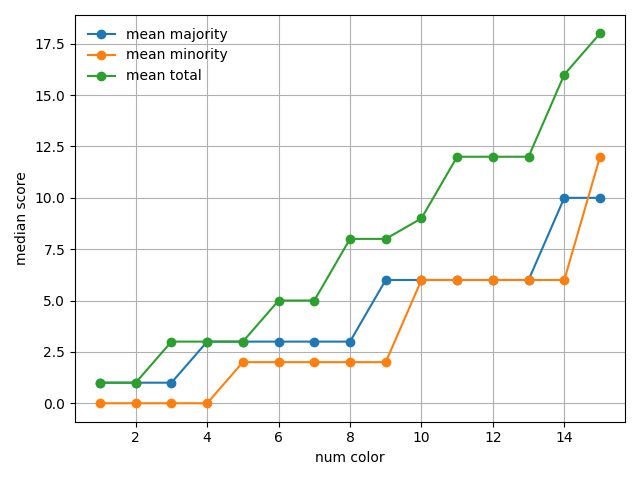

'summaries = [run_many_simulations(\n    num_yellow=n,\n    num_blue=n,\n    num_black=16,\n    black_limit=2,\n    n_simulations=5000,\n    seed=42,\n) for n in range(16, 16*32, 16)]\n\nplot_summaries(summaries, xlabel="num color")'

In [70]:
summaries = [run_many_simulations(
    num_yellow=n,
    num_blue=n,
    num_black=4,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(1, 16)]

plot_summaries(summaries, xlabel="num color")

'''summaries = [run_many_simulations(
    num_yellow=n,
    num_blue=n,
    num_black=16,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(16, 16*32, 16)]

plot_summaries(summaries, xlabel="num color")'''

Roughly quadratic growth with increasing ratio of colored. Minority grows faster than majority, but this is not seen before we have 15 colored per 1 black (up from 3 colored per black). 

Growth is approximately linear between 2.5 --> 7 colored per black. To reach 7 colored per black, 7 needs to be bought each round plus the extra 4*6=24 needed from the start. Quadratic growth is not a huge issue.  

For every 2 per black ball we gain +1 median score. Buying a ball provides an intrinsic +0.5 median score. 

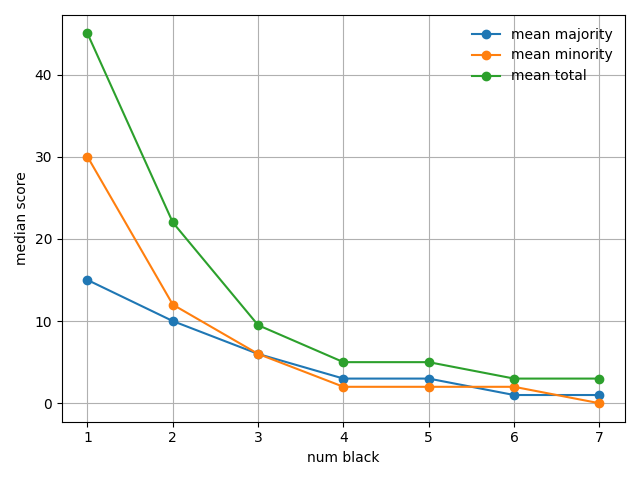

In [64]:
summaries = [run_many_simulations(
    num_yellow=10,
    num_blue=10,
    num_black=n,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(1, 8)]

plot_summaries(summaries, xlabel="num black")

## Score by majority class

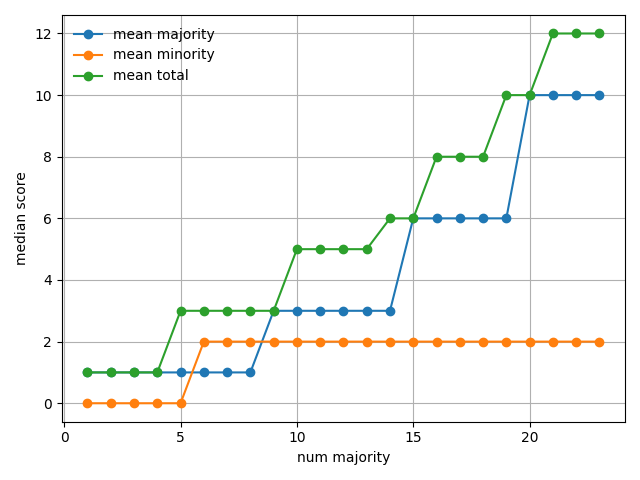

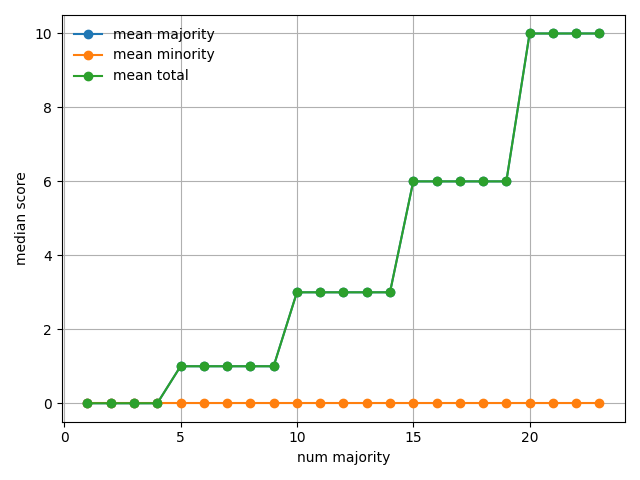

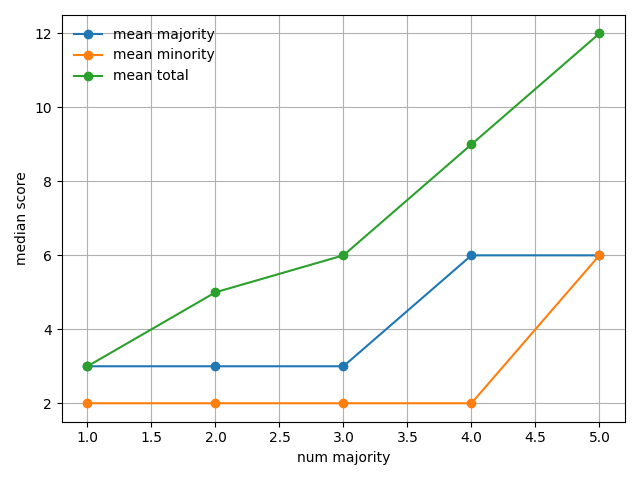

In [23]:
summaries = [run_many_simulations(
    num_yellow=n,
    num_blue=6,
    num_black=4,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(1, 24)]

plot_summaries(summaries, xlabel="num majority")

summaries = [run_many_simulations(
    num_yellow=n,
    num_blue=0,
    num_black=4,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(1, 24)]

plot_summaries(summaries, xlabel="num majority")



Majority cross minority at +3 balls. 9 --> 15 | 3 --> 6 = +0.5 value per ball

    Balls   Even    Majority    Pure
    +4      +2      +2          +2.5
    +6      +3      +2          +4
    +8      +4      +3          +5.5
    +10     +5      +5          +7


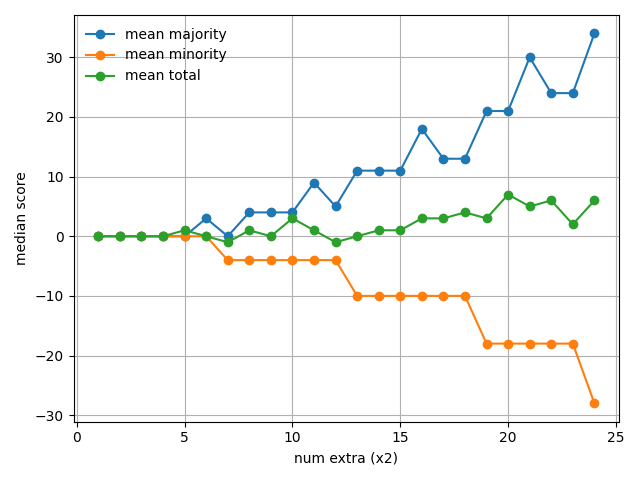

In [36]:
summariesA = [run_many_simulations(
    num_yellow=6 + 2*n,
    num_blue=6,
    num_black=4,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(0, 24)]

summariesB = [run_many_simulations(
    num_yellow=6 + n,
    num_blue=6 + n,
    num_black=4,
    black_limit=2,
    n_simulations=5000,
    seed=42,
) for n in range(0, 24)]

for sa, sb in zip(summariesA, summariesB):
    sa["mean_majority_score"] = sa["mean_majority_score"] - sb["mean_majority_score"]
    sa["mean_minority_score"] = sa["mean_minority_score"] - sb["mean_minority_score"]
    sa["mean_total_score"] = sa["mean_total_score"] - sb["mean_total_score"]

plot_summaries(summariesA, xlabel="num extra (x2)")


Big trend is that focusing on majority color increases score.

If start is [6, 6, 4] --> +5

If start is [12, 6, 4] --> +10

# Balancing

## Effects

## Balls

## Stamps

## Colors